In [11]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import mne

# Enable interactive plots for Jupyter Lab
%matplotlib widget

In [12]:
path = "2023-07-27{D29553B9-1220-4DFC-8456-F712EE2281C8} Data.edf"
raw = mne.io.read_raw_edf(path, preload=False)

Extracting EDF parameters from 2023-07-27{D29553B9-1220-4DFC-8456-F712EE2281C8} Data.edf...
Setting channel info structure...
Creating raw.info structure...


In [13]:
# Extract recording information
n_channels = raw.info['nchan']
ch_names_all = raw.info['ch_names']

# Shorten channel names for neat display in notebook
if len(ch_names_all) > 6:
    ch_names_short = f"{', '.join(ch_names_all[:3])} ... {', '.join(ch_names_all[-3:])}"
else:
    ch_names_short = ", ".join(ch_names_all)

sfreq = raw.info['sfreq']
duration = round(raw.times[-1], 2)

start_time = raw.info['meas_date']
start_time_str = start_time.strftime('%Y-%m-%d %H:%M:%S') if start_time else "No data"
units = "µV (originally) / V (in MNE)" 

# Create summary inventory DataFrame
inventory_data = {
    "Metric": ["Number of channels", "Channel names", "frequency", "duration", "start time", "Units"],
    "Value": [f"{n_channels}", ch_names_short, f"{sfreq} Hz", f"{duration} s", start_time_str, units]
}
df = pd.DataFrame(inventory_data)

# Export full inventory table with all channel names to CSV
df_full = df.copy()
df_full.iloc[1, 1] = ", ".join(ch_names_all)
os.makedirs("tables", exist_ok=True)
df_full.to_csv("tables/inventory_table.csv", index=False, encoding='utf-8')

display(df)

,Metric,Value
0,Number of channels,116
1,Channel names,"RD1, RD2, RD3 ... LTM6, LTM7, LTM8"
2,frequency,1000.0 Hz
3,duration,335.0 s
4,start time,2023-07-27 13:35:20
5,Units,µV (originally) / V (in MNE)


Reading 0 ... 90000  =      0.000 ...    90.000 secs...


EEG channel type selected for re-referencing
Creating RawArray with float64 data, n_channels=103, n_times=90001
    Range : 0 ... 90000 =      0.000 ...    90.000 secs
Ready.
Added the following bipolar channels:
RD1-RD2, RD2-RD3, RD3-RD4, RD4-RD5, RD5-RD6, RD6-RD7, RD7-RD8, RFO1-RFO2, RFO2-RFO3, RFO3-RFO4, RFO4-RFO5, RFO5-RFO6, RFO6-RFO7, RFO7-RFO8, RIP1-RIP2, RIP2-RIP3, RIP3-RIP4, RIP4-RIP5, RIP5-RIP6, RIP9-RIP10, RIP10-RIP11, RIP11-RIP12, RIP12-RIP13, RIP13-RIP14, RIP14-RIP15, RDM1-RDM2, RDM2-RDM3, RDM3-RDM4, RDM4-RDM5, RDM5-RDM6, RDM6-RDM7, RDM7-RDM8, RTS1-RTS2, RTS2-RTS3, RTS3-RTS4, RTS4-RTS5, RTS5-RTS6, RTS6-RTS7, RTS7-RTS8, RTS8-RTS9, RTS9-RTS10, RTS10-RTS11, RTS11-RTS12, RL1-RL2, RL2-RL3, RL3-RL4, RL4-RL5, RL5-RL6, RL6-RL7, RL7-RL8, RIA1-RIA2, RIA2-RIA3, RIA3-RIA4, RIA4-RIA5, RIA5-RIA6, RIA6-RIA7, RIA7-RIA8, RIA8-RIA9, RIA9-RIA10, RIA10-RIA11, RIA11-RIA12, RIA12-RIA13, RIA13-RIA14, RIA14-RIA15, RM1-RM2, RM2-RM3, RM3-RM4, RM4-RM5, RM5-RM6, RM6-RM7, RM7-RM8, LPX1-LPX2, LPX2-LPX3,

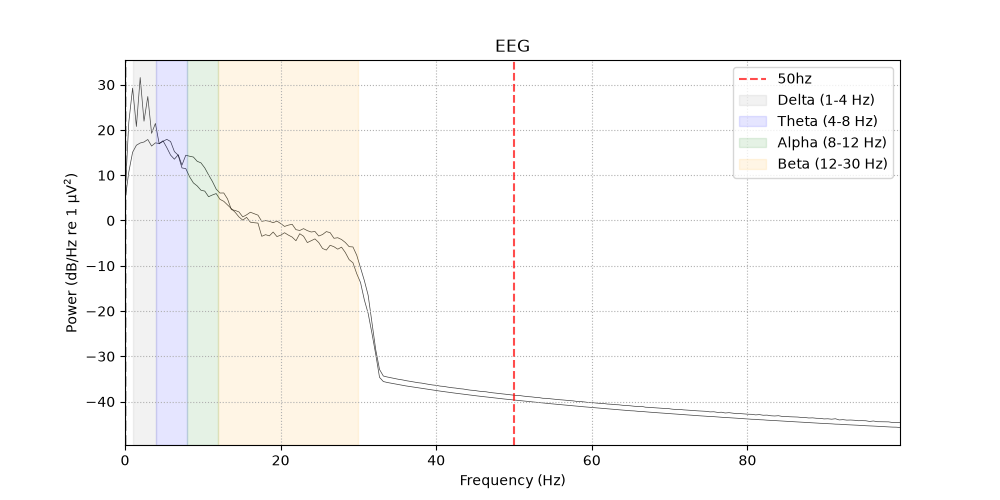

In [14]:
# Crop 90-second segment for analysis
raw_cropped = raw.copy().crop(tmin=0.0, tmax=90.0)
raw_cropped.load_data()

# Automatically build adjacent bipolar channel pairs
ch_names = raw_cropped.ch_names
anode = []
cathode = []

for i in range(len(ch_names) - 1):
    ch1, ch2 = ch_names[i], ch_names[i + 1]
    
    prefix1 = "".join([c for c in ch1 if c.isalpha()])
    num1_str = "".join([c for c in ch1 if c.isdigit()])
    prefix2 = "".join([c for c in ch2 if c.isalpha()])
    num2_str = "".join([c for c in ch2 if c.isdigit()])
    
    if num1_str and num2_str:
        num1, num2 = int(num1_str), int(num2_str)
        # Pair channels if on the same shaft prefix and numbered sequentially
        if prefix1 == prefix2 and (num2 - num1 == 1):
            anode.append(ch1)
            cathode.append(ch2)

# Apply bipolar montage transformation
raw_bipolar = mne.set_bipolar_reference(
    raw_cropped, 
    anode=anode, 
    cathode=cathode, 
    drop_refs=True
)
print(f"Created {len(anode)} valid bipolar pairs.")



# 5. Plot the interactive EEG trace using the bipolar montage
# - n_channels=30: displays 30 channels on screen simultaneously
# - duration=10.0: displays a 10-second viewing window (scrollable up to 90s)
# - scalings='auto': automatically adjusts trace amplitudes for optimal visual clarity
# Note:
# - The X-axis represents time in seconds (s).
# - The Y-axis lists individual bipolar channels, where vertical deflection 
#   represents voltage changes in microvolts (uV).

#save trace
os.makedirs("figures/bipolar_raw", exist_ok=True)
fig_raw_bipolar = raw_bipolar.plot(n_channels=15, duration=10.0, scalings='auto', show=False)
fig_raw_bipolar.savefig("figures/bipolar_raw/raw_bipolar_trace_90s.png", dpi=300)

plt.close(fig_raw_bipolar)
plt.show()



Plotting power spectral density (dB=True).


/tmp/ipykernel_20049/3753592847.py:3: RuntimeWarning: Channel locations not available. Disabling spatial colors.
  fig_psd_raw = psd_raw.plot(average=False, show=False)


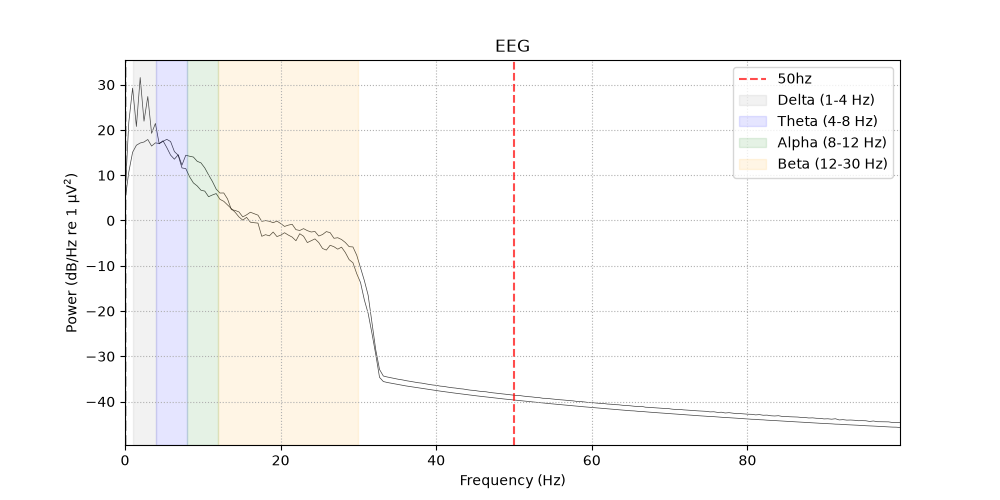

In [15]:

# Save raw un-filtered PSD (0-35 Hz limit)
psd_raw = raw_bipolar.compute_psd(fmin=0, fmax=35, verbose=False)
fig_psd_raw = psd_raw.plot(average=False, show=False)

fig_psd_raw.savefig("figures/bipolar_raw/psd_bipolar_raw.png", dpi=300, bbox_inches="tight")
plt.close(fig_psd_raw)
plt.show()

In [16]:
# ==============================================================================
# SECTION 3: FILTERING (70 Hz vs 250 Hz) & EEG TRACES
# ==============================================================================

output_dir = "figures/filtered_bipolar"
os.makedirs(output_dir, exist_ok=True)

# 1. Apply Notch Filter for powerline noise (50 Hz and harmonics)
notch_freqs = [50, 100, 150, 200, 250]
raw_notch = raw_bipolar.copy().notch_filter(freqs=notch_freqs, fir_design='firwin', verbose=False)

# 2. Create two independent copies for different bandpass limits
raw_70 = raw_notch.copy().filter(l_freq=1.0, h_freq=70.0, fir_design='firwin', verbose=False)
raw_250 = raw_notch.copy().filter(l_freq=1.0, h_freq=250.0, fir_design='firwin', verbose=False)

# A. Single Trace Plot - 1-70 Hz (Black)
fig_trace_70 = raw_70.plot(
    n_channels=15, 
    duration=10.0, 
    remove_dc=True, 
    scalings=dict(eeg=40e-6), 
    color=dict(eeg='black'),
    title="Filtered Bipolar Trace (1-70 Hz)",
    show=False
)
fig_trace_70.savefig(f"{output_dir}/filtered_trace_70Hz.png", dpi=300)
plt.close(fig_trace_70)

# B. Single Trace Plot - 1-250 Hz (Red)
fig_trace_250 = raw_250.plot(
    n_channels=15, 
    duration=10.0, 
    remove_dc=True, 
    scalings=dict(eeg=40e-6), 
    color=dict(eeg='red'),
    title="Filtered Bipolar Trace (1-250 Hz)",
    show=False
)
fig_trace_250.savefig(f"{output_dir}/filtered_trace_250Hz.png", dpi=300)
plt.close(fig_trace_250)

# C. Overlay EEG Trace Plot (Black = 1-70 Hz, Red = 1-250 Hz on top)
n_chans = 15
duration = 10.0
n_samples = int(duration * sfreq)

data_70, times = raw_70.get_data(picks=range(n_chans), start=0, stop=n_samples, return_times=True)
data_250, _ = raw_250.get_data(picks=range(n_chans), start=0, stop=n_samples, return_times=True)
ch_display_names = [raw_70.ch_names[i] for i in range(n_chans)]

fig_trace_overlay, ax_trace = plt.subplots(figsize=(12, 8))
offset = 150e-6  # Vertical spacing between channels (150 uV)

for i in range(n_chans):
    # Plot 1-70 Hz in black (Base layer)
    ax_trace.plot(times, data_70[i] + i * offset, color='black', linewidth=1.2, alpha=0.8, label='1-70 Hz' if i == 0 else "")
    # Plot 1-250 Hz in red (Foreground layer to show high frequencies)
    ax_trace.plot(times, data_250[i] + i * offset, color='red', linewidth=0.8, alpha=0.7, label='1-250 Hz' if i == 0 else "")

ax_trace.set_yticks([i * offset for i in range(n_chans)])
ax_trace.set_yticklabels(ch_display_names)
ax_trace.set_xlabel("Time (s)")
ax_trace.set_title("Overlay Bipolar Trace: 1-70 Hz (Black) vs 1-250 Hz (Red)")
ax_trace.legend(loc="upper right")
plt.tight_layout()

fig_trace_overlay.savefig(f"{output_dir}/filtered_trace_overlay_70_vs_250.png", dpi=300)
plt.close(fig_trace_overlay)

Plotting power spectral density (dB=True).
Plotting power spectral density (dB=True).
Plotting power spectral density (dB=True).
Plotting power spectral density (dB=True).


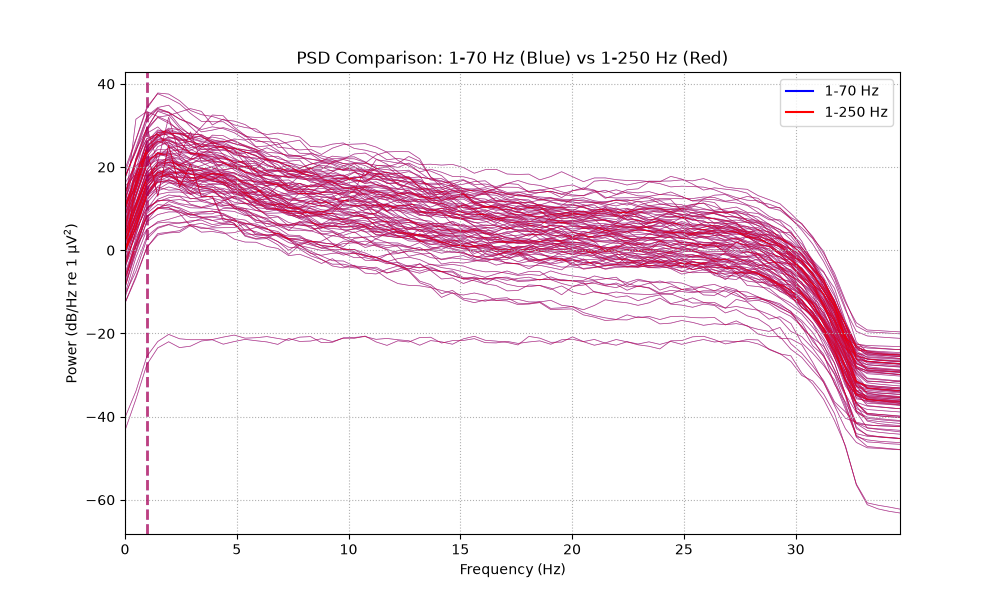

In [17]:
# ==============================================================================
# SECTION 4: POWER SPECTRAL DENSITY (PSD) ANALYSIS
# ==============================================================================

# Compute PSD objects capped at 35 Hz for detailed visualization
psd_70 = raw_70.compute_psd(fmin=0, fmax=35.0, verbose='ERROR')
psd_250 = raw_250.compute_psd(fmin=0, fmax=35.0, verbose='ERROR')

# A. Single PSD - 1-70 Hz (Blue lines)
with warnings.catch_warnings():
    warnings.filterwarnings("ignore", category=RuntimeWarning, message=".*Channel locations not available.*")
    fig_psd_70 = psd_70.plot(average=False, show=False)
    ax = fig_psd_70.get_axes()[0]
    for line in ax.lines:
        line.set_color('blue')
    fig_psd_70.suptitle("PSD - Bipolar Montage (1-70 Hz Filtered)", fontsize=14)
    fig_psd_70.savefig(f"{output_dir}/psd_70Hz.png", dpi=300, bbox_inches="tight")
    plt.close(fig_psd_70)

# B. Single PSD - 1-250 Hz (Red lines)
with warnings.catch_warnings():
    warnings.filterwarnings("ignore", category=RuntimeWarning, message=".*Channel locations not available.*")
    fig_psd_250 = psd_250.plot(average=False, show=False)
    ax = fig_psd_250.get_axes()[0]
    for line in ax.lines:
        line.set_color('red')
    fig_psd_250.suptitle("PSD - Bipolar Montage (1-250 Hz Filtered)", fontsize=14)
    fig_psd_250.savefig(f"{output_dir}/psd_250Hz.png", dpi=300, bbox_inches="tight")
    plt.close(fig_psd_250)

# C. Overlay PSD Comparison (Blue = 1-70 Hz, Red = 1-250 Hz)
# Create interactive Matplotlib overlay plot
fig_psd_overlay, ax_psd = plt.subplots(figsize=(10, 6))

with warnings.catch_warnings():
    warnings.filterwarnings("ignore", category=RuntimeWarning, message=".*Channel locations not available.*")
    
    # 1. Plot 1-70 Hz PSD
    lines_before = len(ax_psd.lines)
    psd_70.plot(axes=ax_psd, average=False, show=False)
    for line in ax_psd.lines[lines_before:]:
        line.set_color('blue')
        line.set_alpha(0.5)
        line.set_picker(False)  # Prevents MNE butterfly pick handler from triggering on click

    # 2. Plot 1-250 Hz PSD
    lines_before = len(ax_psd.lines)
    psd_250.plot(axes=ax_psd, average=False, show=False)
    for line in ax_psd.lines[lines_before:]:
        line.set_color('red')
        line.set_alpha(0.5)
        line.set_picker(False)  # Prevents MNE butterfly pick handler from triggering on click

# Add interactive legend
legend_elements = [
    Line2D([0], [0], color='blue', label='1-70 Hz'),
    Line2D([0], [0], color='red', label='1-250 Hz')
]
ax_psd.legend(handles=legend_elements, loc='upper right')
ax_psd.set_title("PSD Comparison: 1-70 Hz (Blue) vs 1-250 Hz (Red)", fontsize=12)

# Display interactive figure in Jupyter
plt.show()

Effective window size : 2.048 (s)
Plotting power spectral density (dB=True).


/tmp/ipykernel_20049/3189721517.py:1: RuntimeWarning: Channel locations not available. Disabling spatial colors.
  rc35 = raw_bipolar.compute_psd(fmax=35).plot()


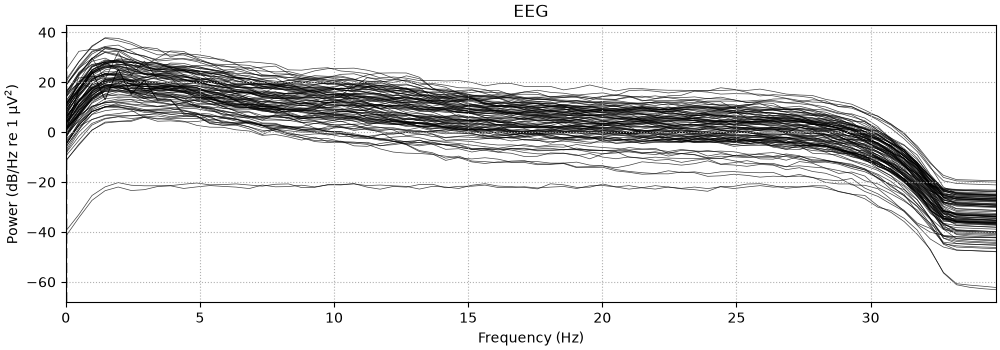

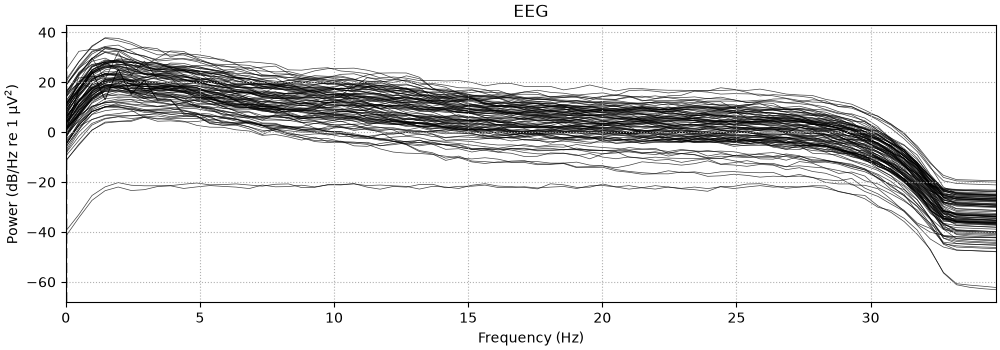

In [18]:
rc35 = raw_bipolar.compute_psd(fmax=35).plot()
#display of psd - x axis to 35
rc35.savefig("figures/filtered_bipolar/psd_bipolar.png")

Effective window size : 2.048 (s)
Plotting power spectral density (dB=True).


/tmp/ipykernel_20049/3596593367.py:9: RuntimeWarning: Channel locations not available. Disabling spatial colors.
  psd_compare.plot(axes=ax, show=False)


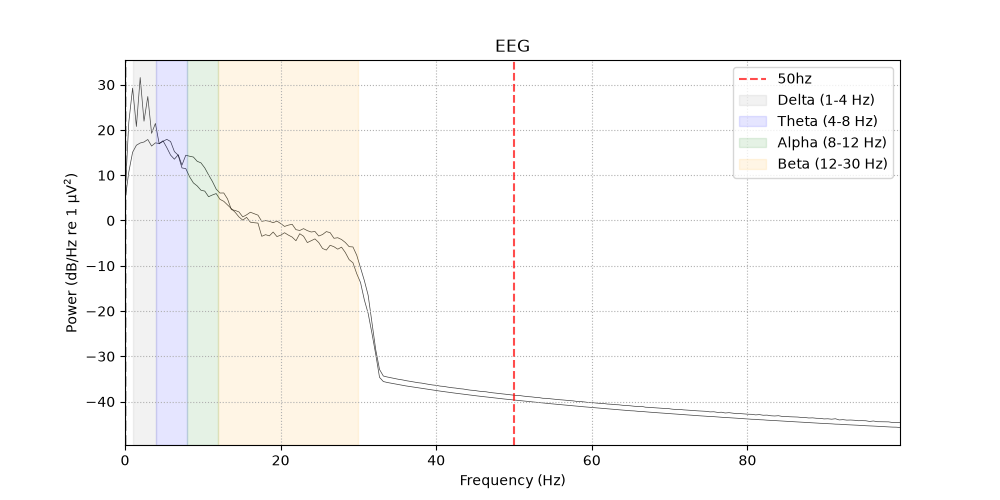

In [19]:
# 1. Select two channels for comparison: one considered "clean", the other "noisy" - in my opinion, both are clean
channels_to_compare = ['LPX12', 'LTM8']

# 2. Compute PSD only for these selected channels
psd_compare = raw_cropped.compute_psd(picks=channels_to_compare, fmax=100)

# 3. Plot the graph
fig, ax = plt.subplots(figsize=(10, 5))
psd_compare.plot(axes=ax, show=False)

# 4. Add reference lines for physiological bands and 50 Hz to make identification easier
ax.axvline(x=50, color='red', linestyle='--', alpha=0.7, label='50hz')
ax.axvspan(1, 4, color='gray', alpha=0.1, label='Delta (1-4 Hz)')
ax.axvspan(4, 8, color='blue', alpha=0.1, label='Theta (4-8 Hz)')
ax.axvspan(8, 12, color='green', alpha=0.1, label='Alpha (8-12 Hz)')
ax.axvspan(12, 30, color='orange', alpha=0.1, label='Beta (12-30 Hz)')

# Refresh the legend and display the plot
ax.legend()
plt.show()

In [20]:
# Extract clean data and channel names
data, times = raw_bipolar.get_data(return_times=True)
ch_names = raw_bipolar.ch_names

summary_data = []

for i, name in enumerate(ch_names):
    channel_signal = data[i, :]
    
    # Basic statistics
    ch_mean = np.mean(channel_signal)
    ch_std = np.std(channel_signal)
    ch_min = np.min(channel_signal)
    ch_max = np.max(channel_signal)
    
    # Differences between adjacent samples (to detect perfectly flat lines)
    diffs = np.diff(channel_signal)
    # % sample-by-sample where the change is exactly 0
    pct_flat = (np.sum(diffs == 0) / len(diffs)) * 100
    
    # % samples where the signal reaches extreme values for this channel (saturation)
    # (due to quantization noise, we check very close to maximums/minimums)
    is_saturated = (channel_signal == ch_min) | (channel_signal == ch_max)
    pct_saturated = (np.sum(is_saturated) / len(channel_signal)) * 100
    
    # Flagging based on criteria:
    # - If the standard deviation is extremely low (e.g., < 1e-7) or %flat is high -> FLAT
    # - If the signal touches limits too frequently -> RAILED/SATURATED
    # - If std is suspiciously huge -> BAD
    status = "OK"
    if ch_std < 1e-7 or pct_flat > 10.0:
        status = "BAD (Flat)"
    elif pct_saturated > 1.0:
        status = "BAD (Railed/Saturated)"
    elif ch_std > 500e-6:  # Example threshold for SEEG (500 µV)
        status = "BAD (High Noise)"
        
    summary_data.append({
        "Channel": name,
        "Mean": ch_mean,
        "Std": ch_std,
        "Min": ch_min,
        "Max": ch_max,
        "% Flat": pct_flat,
        "% Saturated": pct_saturated,
        "Status": status
    })

# 2. Create DataFrame and format numbers nicely
df_summary = pd.DataFrame(summary_data)
pd.set_option('display.max_rows', None)  # To display all channels

# Display the table
df_summary




# 3) Bad-channel bar chart from df_summary
if 'df_summary' not in globals():
    csv_path = "figures/channel_quality_summary.csv"
    if os.path.exists(csv_path):
        df_summary = pd.read_csv(csv_path)
    else:
        raise NameError("Missing df_summary and missing channel_quality_summary.csv — run the channel quality analysis cell first.")

status_counts = df_summary['Status'].value_counts()
fig, ax = plt.subplots(figsize=(6,4))
colors = ['red' if 'BAD' in s else 'green' for s in status_counts.index]
status_counts.plot.bar(ax=ax, color=colors)
ax.set_ylabel('Number of channels')
ax.set_title('Channel quality summary')
plt.tight_layout()
fig.savefig('figures/bad_channels_bar.png')
plt.close(fig)
print('Saved: figures/bad_channels_bar.png')

Saved: figures/bad_channels_bar.png
